In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv


## 🟢 1. Import Required Libraries

In [2]:
# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 🟢 2. Load the Dataset

In [8]:
# Load Iris dataset
iris = pd.read_csv("/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv")

# Display first 5 rows
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 🟢 3. Dataset Overview

### Shape of Dataset

In [10]:
iris.shape

(150, 5)

### Column Names

In [11]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

### First Few Rows

In [12]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Summary Statistics

In [13]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Dataset Info

In [14]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Dataset Overview Insights

The dataset contains 150 observations with 4 numerical features:

Sepal Length
Sepal Width
Petal Length
Petal Width

It includes **3 species categories:**

Setosa
Versicolor
Virginica

No missing values were observed, indicating a clean dataset suitable for analysis.

## 🟢 4. Data Visualization

### 4.1 Scatter Plot (Feature Relationships)

<Figure size 1000x800 with 0 Axes>

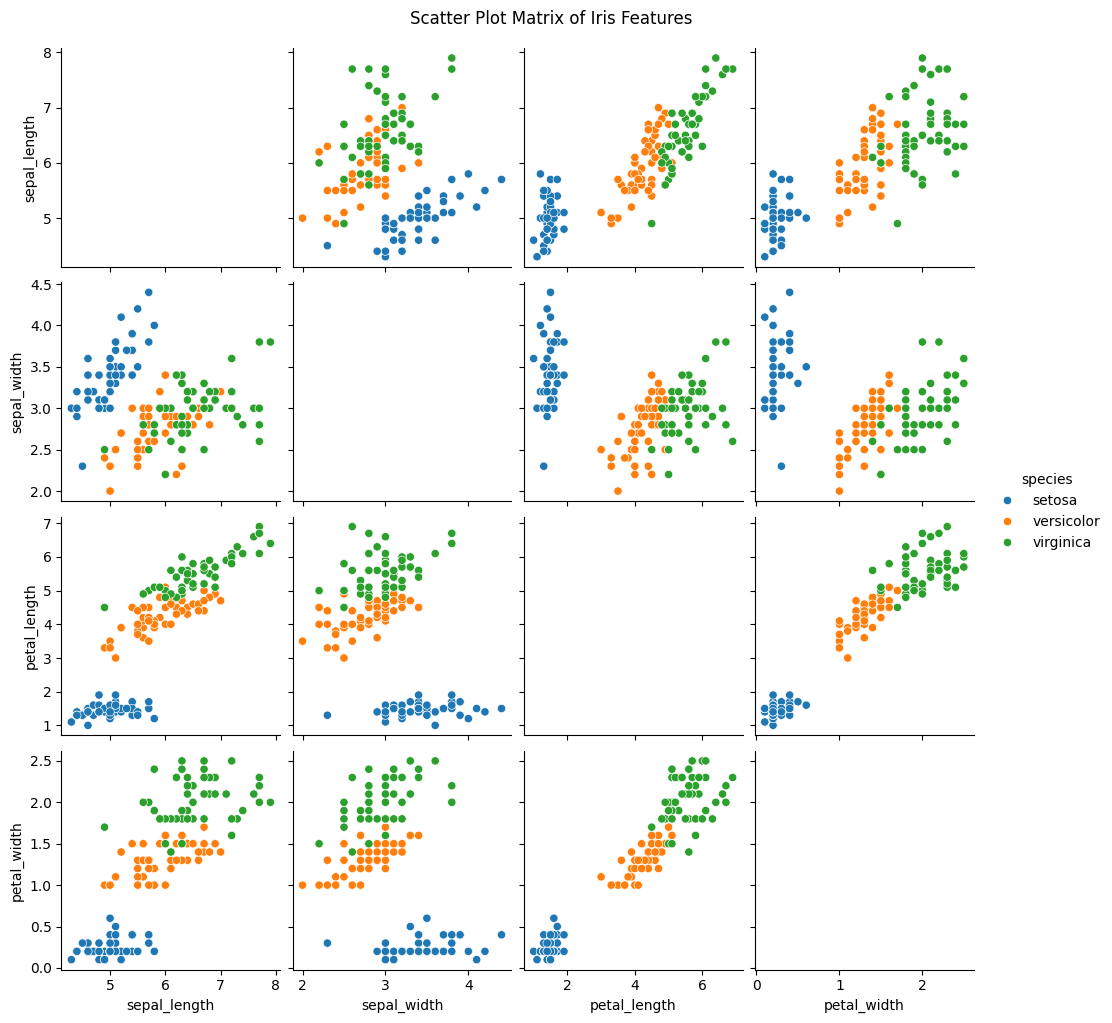

In [16]:
plt.figure(figsize=(10,8))
sns.pairplot(iris, hue='species', diag_kind='scatter')

plt.suptitle("Scatter Plot Matrix of Iris Features", y=1.02)
plt.show()

### Scatter Plot (Pairplot) Insights

Petal Length vs Petal Width shows a strong positive correlation.

Species are clearly separable based on petal features:

Setosa is distinctly clustered and easily separable.

Versicolor and Virginica show some overlap but are still distinguishable.

Sepal features show less clear separation, meaning they are less effective for classification compared to petal features.

**👉 Key Insight:**
Petal measurements are more informative for distinguishing species than sepal measurements.

### 4.2 Histograms by Species (Data Distribution)

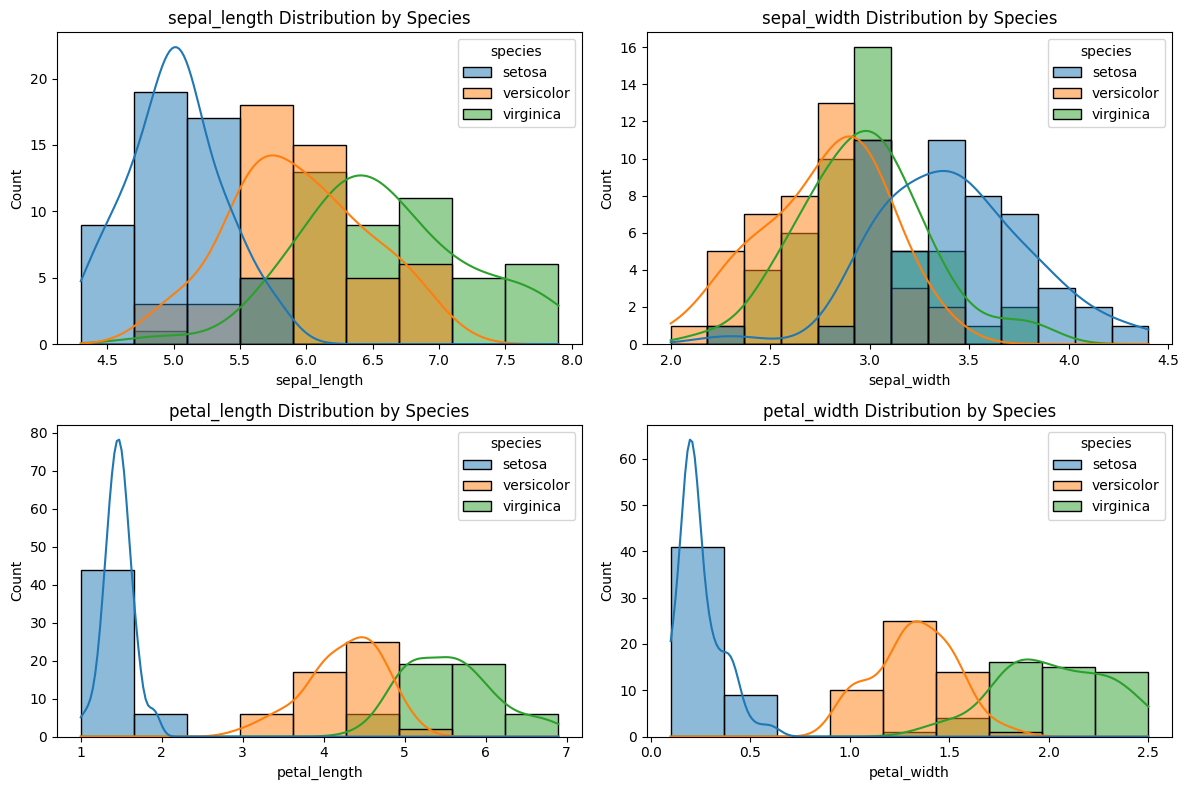

In [18]:
features = iris.columns[:-1]

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=iris, x=col, hue='species', kde=True)
    plt.title(f'{col} Distribution by Species')

plt.tight_layout()
plt.show()

### Histogram Insights (Feature Distribution)

Most features show a roughly normal (bell-shaped) distribution.

Petal length and width show multi-modal distributions, indicating different species groups.

Sepal width has a slightly skewed distribution, suggesting variability in that feature.

**👉 Key Insight:**
Different peaks in histograms suggest the presence of distinct classes within the dataset.

### 4.3 Box Plot (Outliers Detection)

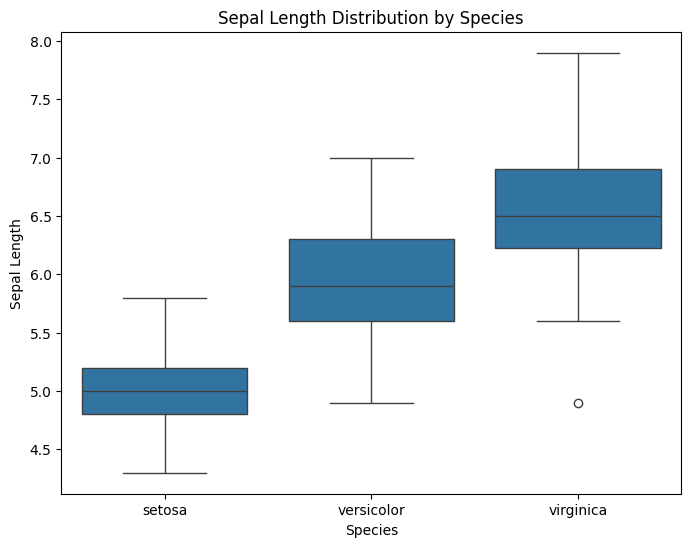

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=iris,
    x='species',
    y='sepal_length'
)

plt.title('Sepal Length Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.show()

### Box Plot Insights (Outliers & Spread)

Setosa has very small variation in petal length and width.

Virginica shows larger spread, indicating higher variability.

Some outliers are present, especially in sepal width.

**👉 Key Insight:**

Variation differs across species, with Virginica being the most diverse.

### 4.4 Pairplot with Histograms

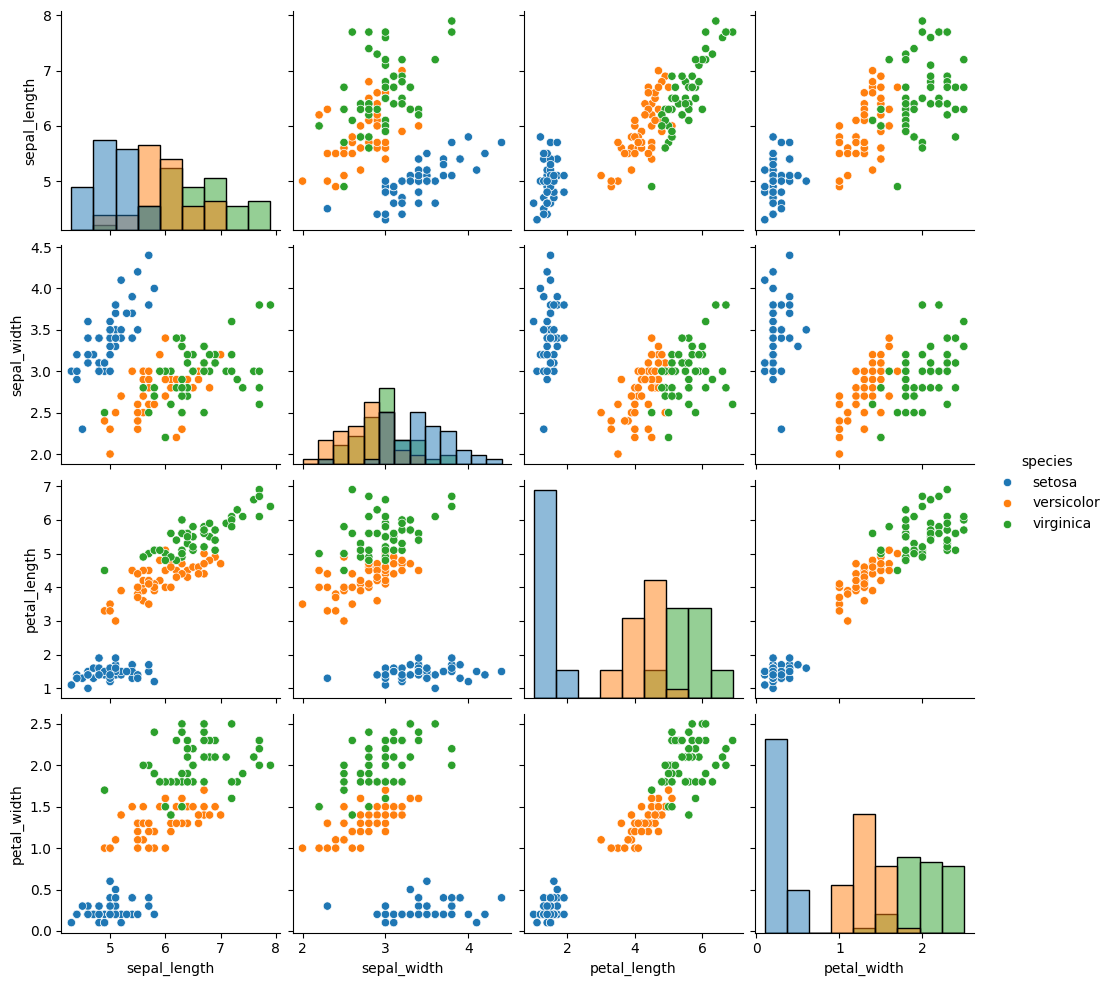

In [19]:
sns.pairplot(iris, hue='species', diag_kind='hist')
plt.show()

### 4.5 Heatmap (Correlation Analysis Among Features)

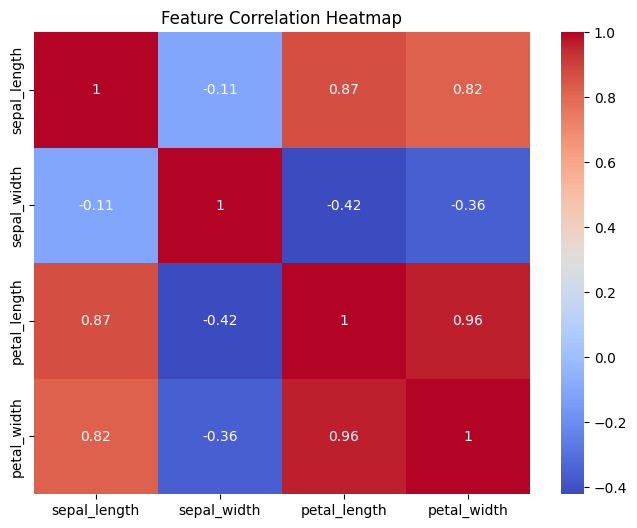

In [20]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(iris.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

### Insights From Heatmap

**High correlation between:**
Petal Length & Petal Width

**Weak correlation between:** 
Sepal Width and other features

**👉 Key Insight:**
Some features may be redundant due to strong correlation.